In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [4]:
df = pd.read_csv('..\\data\\mega_FA_bathy.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,FA,ps_z,stein_z,bathy
0,49.62,-129.98,0.816961,366.0,523.431597,564.247252,2.029732,2816.350677,2929.908563,-2408
1,44.68,-125.29,9.119624,79.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2114
2,44.66,-125.27,9.119624,81.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
3,44.66,-125.27,9.119624,93.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
4,44.66,-125.26,9.119624,77.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2280


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [5]:
x = df.drop(columns=['q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [6]:
x.head()

,lat,long,age,q_ihfc,bathy
0,49.62,-129.98,0.816961,366.0,-2408
1,44.68,-125.29,9.119624,79.0,-2114
2,44.66,-125.27,9.119624,81.0,-2269
3,44.66,-125.27,9.119624,93.0,-2269
4,44.66,-125.26,9.119624,77.0,-2280


In [7]:
x.shape

(7445, 5)

In [8]:
y.head()

0     2.029732
1   -66.546684
2   -66.546684
3   -66.546684
4   -66.546684
Name: FA, dtype: float64

In [9]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [10]:
x_train.shape

(5956, 5)

this is the raw validation data

In [11]:
x_test.shape

(1489, 5)

In [12]:
x_train.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,5956.000,5956.000,5956.000,5956.000,5956.000
mean,46.188,-125.755,6.208,600.253,-1247.046
std,3.551,3.560,5.982,1628.433,1682.000
min,37.030,-132.370,0.021,-182.200,-4764.000
25%,44.558,-128.680,0.804,87.000,-2585.000
50%,47.860,-127.680,3.495,190.000,-2420.000
75%,48.450,-122.530,9.544,418.000,556.250
max,54.940,-119.000,35.200,25680.000,2860.000


In [13]:
x_test.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,1489.000,1489.000,1489.000,1489.000,1489.000
mean,46.130,-125.657,6.364,643.276,-1214.326
std,3.538,3.551,6.044,1788.185,1693.941
min,37.030,-132.420,0.010,-42.400,-4658.000
25%,44.430,-128.670,0.867,85.000,-2583.000
50%,47.840,-127.580,3.847,187.000,-2400.000
75%,48.440,-122.310,9.546,403.000,600.000
max,54.940,-119.000,33.401,26000.000,2860.000


In [14]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

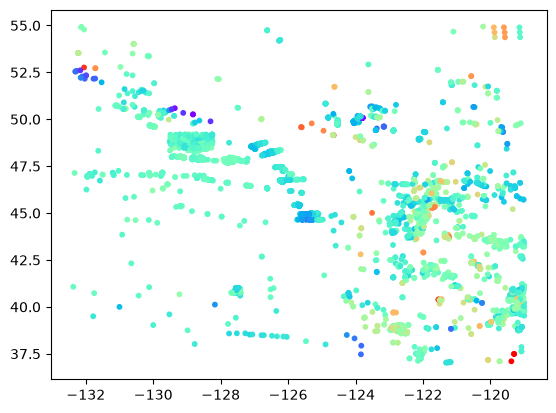

In [15]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

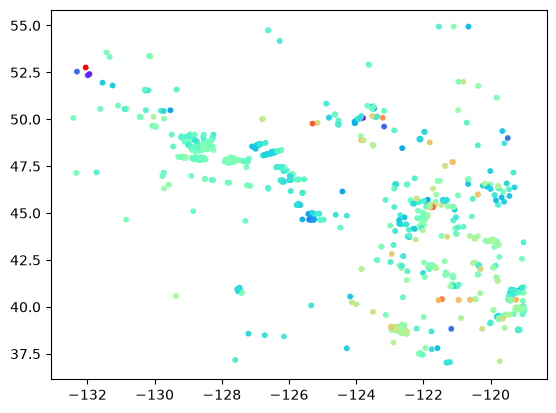

In [16]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [17]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [18]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1244
[LightGBM] [Info] Number of data points in the train set: 5956, number of used features: 5
[LightGBM] [Info] Start training from score -6.942879


In [19]:
y_pred = model.predict(x_test)

In [20]:
y_pred.shape

(1489,)

In [21]:
y_pred, y_pred.shape

(array([ 60.02445848, -24.38439995,   2.97948652, ...,   3.84219653,
        -25.26831848,  19.46126026], shape=(1489,)),
 (1489,))

In [22]:
residuals = y_test - y_pred

negative mean: overpredicting

In [23]:
residuals.head(), residuals.describe()

(6878   -18.032519
 421     -6.329162
 5700     1.262394
 5510    14.188697
 3641   -25.225134
 Name: FA, dtype: float64,
 count    1489.000000
 mean        0.054187
 std        10.500761
 min      -100.520645
 25%        -2.082166
 50%        -0.177300
 75%         1.698209
 max        77.624654
 Name: FA, dtype: float64)

In [24]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [25]:
pd.DataFrame(dfr).to_csv('..\\created_data\\Ebth_grav_residuals.csv', index=False)

with open('..\\created_data\\Ebth_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'and this was for lat, long, age, ihfc, and bathy')

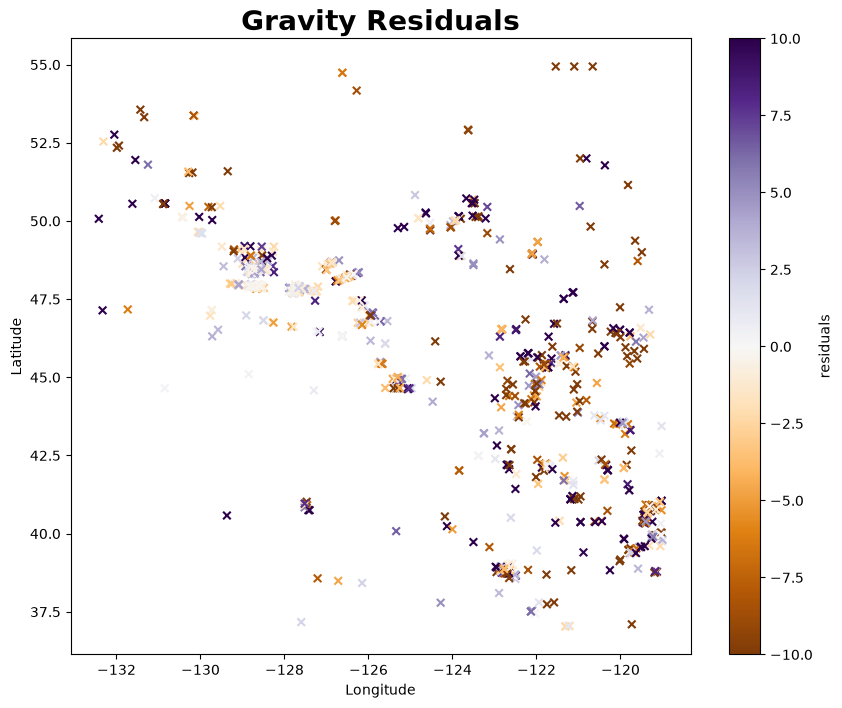

In [26]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\Ebth_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

we start with just predicting the same area on an empty grid

In [27]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [28]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [29]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [30]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [31]:
np.where(~np.isnan(age_interp))

(array([  1,   1,   1, ..., 249, 249, 249], shape=(59365,)),
 array([147, 148, 149, ..., 224, 225, 226], shape=(59365,)))

In [32]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[77.10461119, 75.19653423, 73.28845727, 71.38038031, 69.47230335],
        [77.75178328, 75.84370632, 73.93562936, 72.0275524 , 70.11947544],
        [78.39895537, 76.49087841, 74.58280145, 72.67472449, 70.76664753],
        [79.04612746, 77.1380505 , 75.22997354, 73.32189658, 71.41381962],
        [79.69329955, 77.78522259, 75.87714563, 74.0763582 , 72.281206  ]]),
 array([[8.47621264, 8.53690558, 8.59759852, 8.65829146, 8.71898439],
        [8.49692884, 8.55762178, 8.61831472, 8.67900766, 8.7397006 ],
        [8.51764505, 8.57833799, 8.63903092, 8.69972386, 8.7604168 ],
        [8.53836125, 8.59905419, 8.65974713, 8.72044007, 8.78113301],
        [8.55907745, 8.61977039, 8.68046333, 8.73057528, 8.78013149]]),
 array([[-1856.76505906, -1759.20007345, -1661.63508783, -1564.07010222,
         -1466.5051166 ],
        [-1830.26350973, -1732.69852411, -1635.1335385 , -1537.56855288,
         -1440.00356727],
        [-1803.76196039, -1706.19697478, -1608.63198916, -1511.06700355,


In [33]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((250, 250), (250, 250), (250, 250))

np.vstack stacks arrays as new rows

In [34]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [35]:
lola.shape

(62500, 5)

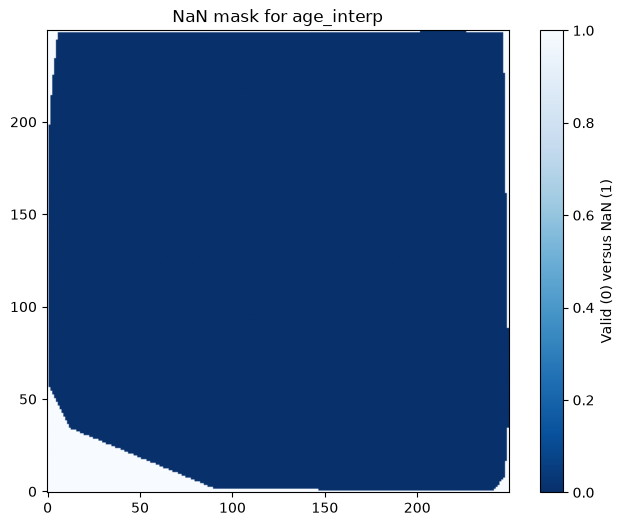

In [36]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [37]:
lola_pred = model.predict(lola)

In [38]:
lola_pred[180:184]

array([-16.70273413, -16.70273413, -16.70273413, -16.70273413])

In [39]:
lola_pred = lola_pred.reshape(long.shape)

In [40]:
lola_pred.shape

(250, 250)

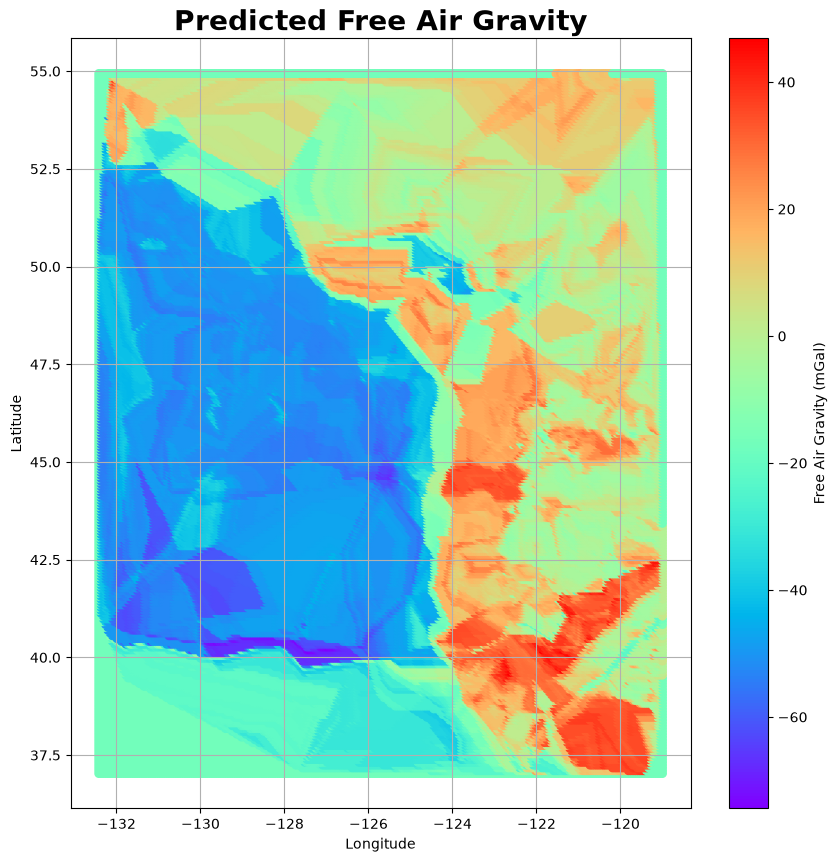

In [41]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\Ebth_grav_pred_{sp}.png', dpi=400)
plt.show()

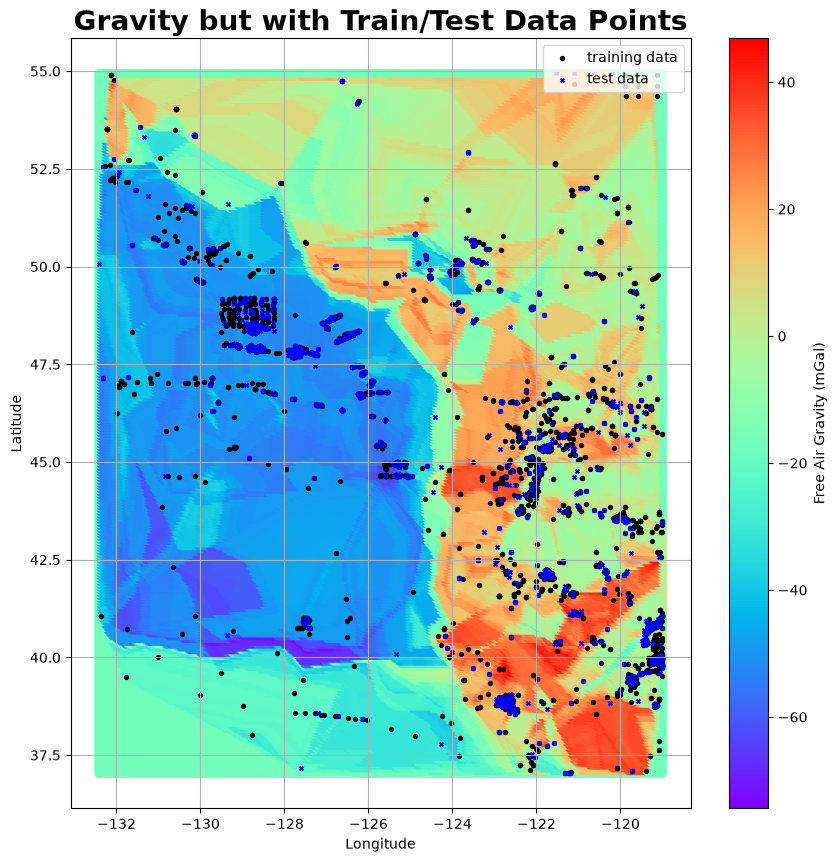

In [42]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=8, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=8, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\Ebth_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()

## now the predicton will be from a specified area...

In [43]:
sp = 500
grid_long = np.linspace(-128.88, -128.33, sp)
grid_lat = np.linspace(47.8, 48.6, sp)

In [44]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [45]:
long.shape, lat.shape

((500, 500), (500, 500))

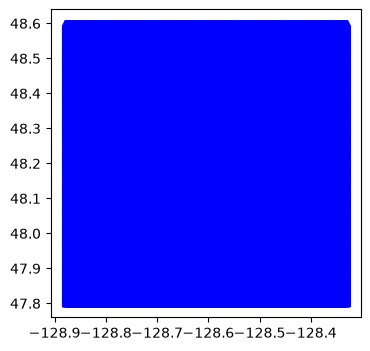

In [46]:
plt.figure(figsize=(4, 4))
plt.plot(long, lat, marker='^', markersize=5, color='blue', linestyle='none')
plt.show()

In [47]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [48]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 499, 499, 499], shape=(250000,)),
 array([  0,   1,   2, ..., 497, 498, 499], shape=(250000,)))

In [49]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[234.48337545, 234.70333711, 234.92329877, 235.14326043,
         235.3632221 ],
        [236.12422236, 236.34418402, 236.56414568, 236.78410735,
         237.00406901],
        [237.76506927, 237.98503093, 238.20499259, 238.42495426,
         238.64491592],
        [239.40591618, 239.62587784, 239.84583951, 240.06580117,
         240.28576283],
        [241.04676309, 241.26672475, 241.48668642, 241.70664808,
         241.92660974]]),
 array([[0.60585981, 0.60786534, 0.60987087, 0.61187639, 0.61388192],
        [0.60650327, 0.6085088 , 0.61051433, 0.61251986, 0.61452539],
        [0.60714673, 0.60915226, 0.61115779, 0.61316332, 0.61516885],
        [0.6077902 , 0.60979573, 0.61180126, 0.61380678, 0.61581231],
        [0.60843366, 0.61043919, 0.61244472, 0.61445025, 0.61645578]]),
 array([[-2578.48357585, -2578.33981005, -2578.19604426, -2578.05227847,
         -2577.90851268],
        [-2577.91199791, -2577.76823212, -2577.62446632, -2577.48070053,
         -2577.33693474],
   

In [50]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((500, 500), (500, 500), (500, 500))

In [51]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [52]:
lola.shape

(250000, 5)

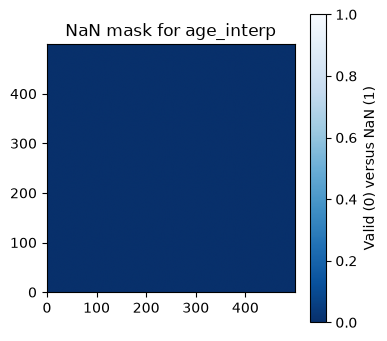

In [53]:
np.where(np.isnan(lola))

plt.figure(figsize=(4,4))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [54]:
lola_pred = model.predict(lola)

In [55]:
lola_pred[180:184]

array([-47.94720557, -47.94720557, -47.94720557, -47.94720557])

In [56]:
lola_pred = lola_pred.reshape(long.shape)

In [57]:
lola_pred.shape

(500, 500)

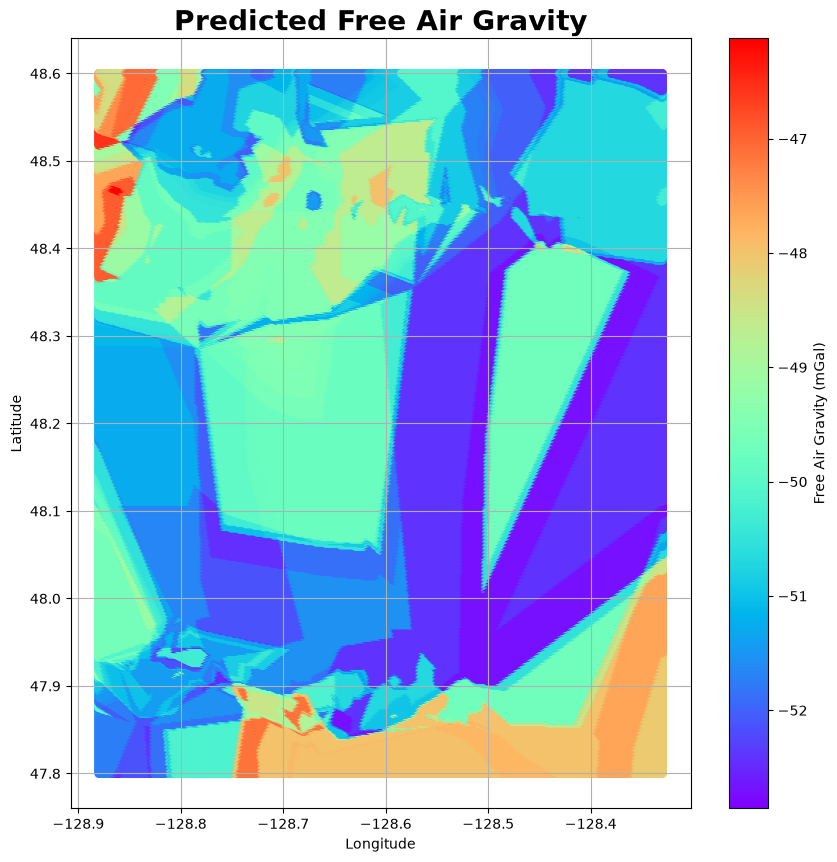

In [58]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\Esmall_grav_pred_{sp}.png', dpi=400)
plt.show()

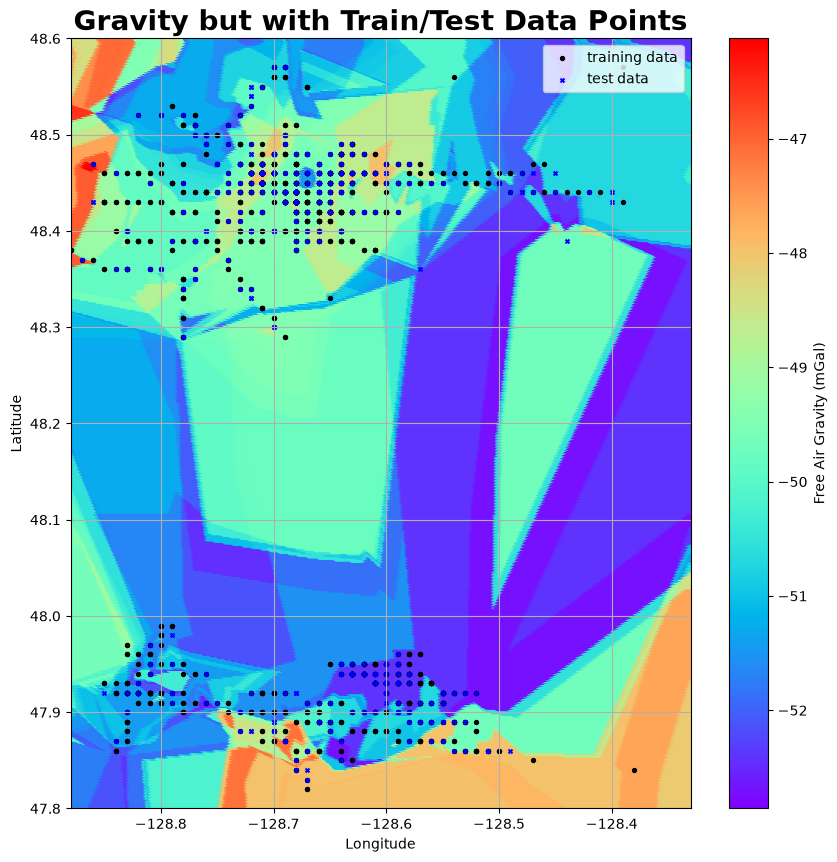

In [59]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=8, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=8, label='test data')
plt.xlim(-128.88, -128.33)
plt.ylim(47.8, 48.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\Esmall_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()